In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import json
import typing as ty
from sklearn.model_selection import train_test_split
import torch
import time
from mlp import Standalone_RealMLP_TD_S_Classifier, Standalone_RealMLP_TD_S_Regressor
np.random.seed(1)
torch.manual_seed(1)

In [2]:
data_name = "allrep"
data_path = "../data/data/"

def load_json(path):
    return json.loads(Path(path).read_text())

def dataname_to_numpy(dataset_name, dataset_path):

    """
    Load the dataset from the numpy files.

    :param dataset_name: str
    :param dataset_path: str
    :return: Tuple[ArrayDict, ArrayDict, ArrayDict, Dict[str, Any]]
    """
    dir_ = Path(os.path.join(dataset_path, dataset_name))

    def load(item):
        return {
            x: ty.cast(np.ndarray, np.load(dir_ / f'{item}_{x}.npy', allow_pickle = True))  
            for x in ['train', 'val', 'test']
        }

    return (
        load('N') if dir_.joinpath('N_train.npy').exists() else None,
        load('C') if dir_.joinpath('C_train.npy').exists() else None,
        load('y'),
        load_json(dir_ / 'info.json'),
    )

def get_dataset(dataset_name, dataset_path):
    """
    Load the dataset from the numpy files.

    :param dataset_name: str
    :param dataset_path: str
    :return: Tuple[ArrayDict, ArrayDict, ArrayDict, Dict[str, Any]]
    """
    N, C, y, info = dataname_to_numpy(dataset_name, dataset_path)
    N_trainval = None if N is None else {key: N[key] for key in ["train", "val"]} if "train" in N and "val" in N else None
    N_test = None if N is None else {key: N[key] for key in ["test"]} if "test" in N else None

    C_trainval = None if C is None else {key: C[key] for key in ["train", "val"]} if "train" in C and "val" in C else None
    C_test = None if C is None else {key: C[key] for key in ["test"]} if "test" in C else None

    y_trainval = {key: y[key] for key in ["train", "val"]}
    y_test = {key: y[key] for key in ["test"]} 
    
    # tune hyper-parameters
    train_val_data = (N_trainval,C_trainval,y_trainval)
    test_data = (N_test,C_test,y_test)
    return train_val_data,test_data,info

In [21]:
train_val_data, test_data, info = get_dataset(data_name, data_path)
num_features, cat_features, labels = train_val_data
# Concatenate numerical and categorical features column-wise
num_features = pd.DataFrame(np.concatenate((num_features["train"], num_features["val"]), axis=0))
cat_features = pd.DataFrame(np.concatenate((cat_features["train"], cat_features["val"]), axis=0))
X = pd.concat([num_features, cat_features], axis=1)
# Concatenate train and val into a single dataset
# X = np.concatenate((X_train, X_val), axis=0)
y = np.concatenate((labels["train"], labels["val"]), axis=0)

#Repeating the same process for test set
num_features_test, cat_features_test, labels_test = test_data
num_features_test = pd.DataFrame(num_features_test["test"])
cat_features_test = pd.DataFrame(cat_features_test["test"])
X_test = pd.concat([num_features_test, cat_features_test], axis=1)
y_test = labels_test["test"]

n_valid = 604
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=n_valid, random_state=42)

classification = True
loss_type = 'rps'
ts_type = "lbfgs"
n_repeats = 1
preds = []
seed_offset=1000
train_losses, test_losses, refinement_losses, calib_losses = [], [], [], []

# start_time = time.time()
for i in range(n_repeats):
    print(f'Round {i}')
    seed = i + seed_offset
    np.random.seed(seed)
    torch.manual_seed(seed)
    if classification:
        mlp = Standalone_RealMLP_TD_S_Classifier(loss_type=loss_type, ts_type=ts_type)
    else:
        mlp = Standalone_RealMLP_TD_S_Regressor()
    mlp, train_loss, test_loss, refinement_loss, calib_loss = mlp.fit(X_train, y_train, X_val, y_val, X_test, y_test)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    refinement_losses.append(refinement_loss)
    calib_losses.append(calib_loss)

Round 0


/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/elnurazhalieva/miniconda3/envs/scoring/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Returning from fit() method


In [4]:
import matplotlib.pyplot as plt

In [22]:
train_losses = np.array(train_losses[0])  # Shape (10, 150)
test_losses = np.array(test_losses[0])  # Shape (10, 150)
refinement_losses = np.array(refinement_losses[0])  # Shape (10, 150)
calib_losses = np.array(calib_losses[0])  # Shape (10, 150)

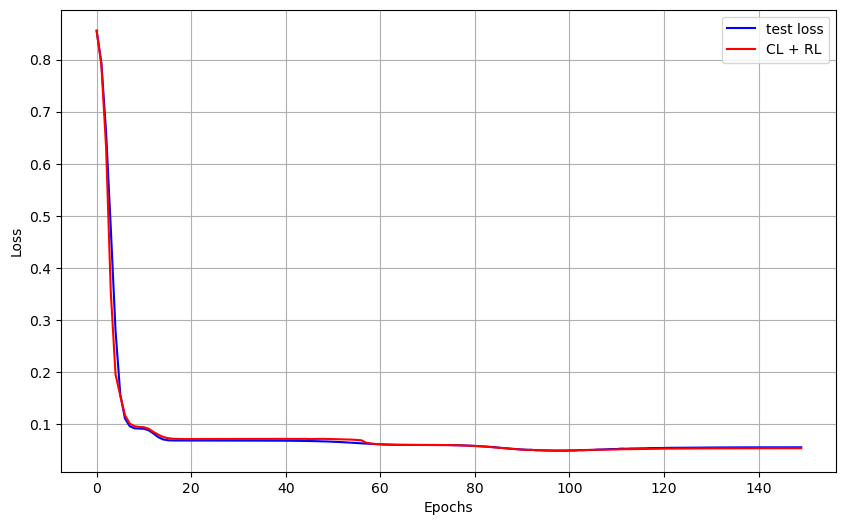

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(test_losses, label = "test loss", color = "blue")
plt.plot(calib_losses+refinement_losses, label = "CL + RL", color = "red")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid()
# plt.savefig("figures/realmlp_rps_bisection_sum.png", dpi=300, bbox_inches='tight')
plt.show()

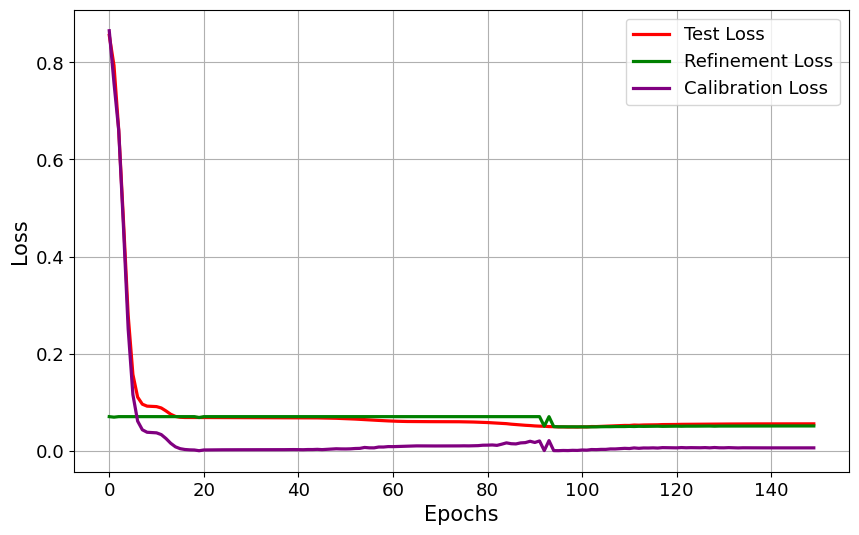

In [20]:
# train_losses = np.array(train_losses)  # Shape (10, 150)
# test_losses = np.array(test_losses)  # Shape (10, 150)
# refinement_losses = np.array(refinement_losses)  # Shape (10, 150)
# calib_losses = np.array(calib_losses)  # Shape (10, 150)

n_epochs = train_losses.shape[0]

# Compute mean and standard error across 10 runs
# train_mean = np.mean(train_losses, axis=0)
# train_std = np.std(train_losses, axis=0, ddof=1)

# test_mean = np.mean(test_losses, axis=0)
# test_std = np.std(test_losses, axis=0, ddof=1)

# refinement_mean = np.mean(refinement_losses, axis=0)
# refinement_std = np.std(refinement_losses, axis=0, ddof=1)

# calib_mean = np.mean(calib_losses, axis=0)
# calib_std = np.std(calib_losses, axis=0, ddof=1)

# Plot each loss with standard error
plt.figure(figsize=(10, 6))

# plt.plot(train_mean, label="Train Loss", color='blue')
# plt.fill_between(range(n_epochs), train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')

plt.plot(test_losses, label="Test Loss", color='red', linewidth=2.3)
# plt.fill_between(range(n_epochs), test_mean - test_std, test_mean + test_std, alpha=0.2, color='red', linewidth=2)

plt.plot(refinement_losses, label="Refinement Loss", color='green', linewidth=2.3)
# plt.fill_between(range(n_epochs), refinement_mean - refinement_std, refinement_mean + refinement_std, alpha=0.2, color='green', linewidth=2)

plt.plot(calib_losses, label="Calibration Loss", color='purple', linewidth=2.3)
# plt.fill_between(range(n_epochs), calib_mean - calib_std, calib_mean + calib_std, alpha=0.2, color='purple', linewidth=2)

plt.xlabel("Epochs", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.xticks(fontsize=13)  # Increase x-axis tick size
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.grid()
plt.savefig("figures/realmlp_rps_bisection.png", dpi=300, bbox_inches='tight')
plt.show()